In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent)) 

### Preprocessing

BBox points(8,3) -> Parametrization(center, size, rotation)

In [14]:
from src.dataset import Custom3DDataset
from src.preprocess import box_to_param

dataset = Custom3DDataset(path="../data")
sample = dataset[2]

center, size, yaw = box_to_param(sample["bbox3d"][0])
print(center, size, yaw)

[0.04428345 0.04575487 0.99915373] [0.2378852  0.20258989 0.178119  ] 0.7031451683167174


Validation

In [15]:
import numpy as np
from src.preprocess import param_to_box, box_to_param

def reconstruct_bboxes(sample):
    reconstructed_bboxes = []
    for i in range(sample["bbox3d"].shape[0]):
        center, size, yaw = box_to_param(sample["bbox3d"][i])
        reconstructed = param_to_box(center, size, yaw)
        reconstructed_bboxes.append(reconstructed)
    return reconstructed_bboxes

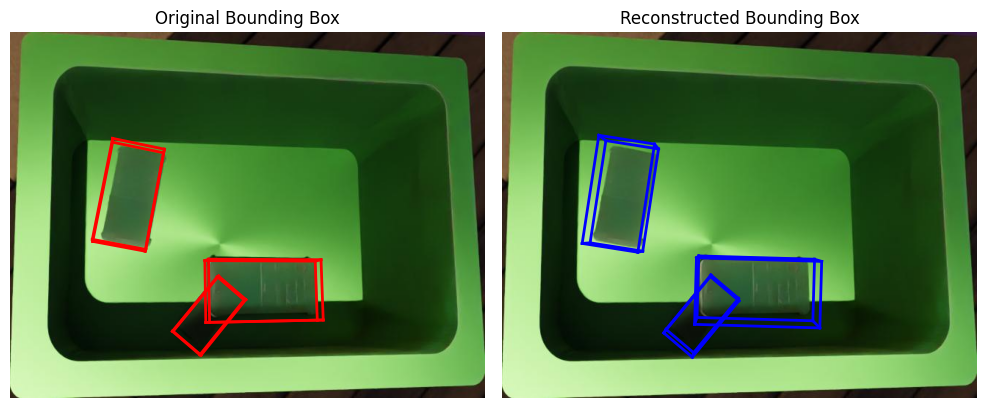

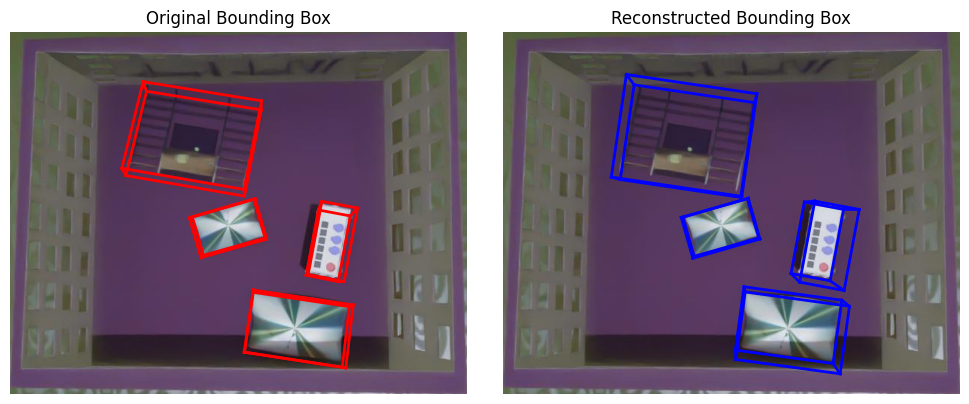

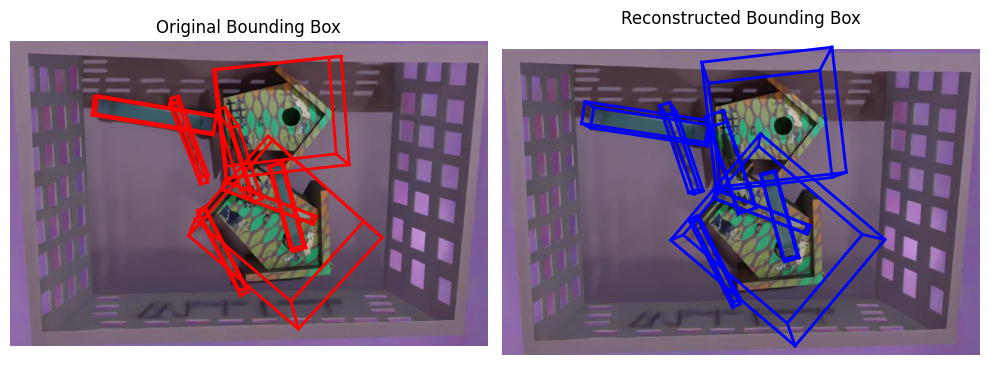

In [ ]:
import matplotlib.pyplot as plt
from src.visualize import Visualizer

for i in range(3):
    vis = Visualizer(dataset[i])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    vis.show(show_pc=False, show_boxes=True, show_mask=False, ax=ax1)
    ax1.set_title("Original Bounding Box")

    vis.boxes = reconstruct_bboxes(dataset[i])
    vis.show(show_pc=False, show_boxes=True, show_mask=False, box_color='b', ax=ax2)
    ax2.set_title("Reconstructed Bounding Box")

    plt.tight_layout()
    plt.show()

### Object Extraction (Starting with object level learning)

In [3]:
from src.dataset import Custom3DDataset
from src. preprocess import extract_objects, preprocess_object

dataset = Custom3DDataset(path="../data")
objects = extract_objects(dataset[0])
print(len(objects[2]["points"]))

8372


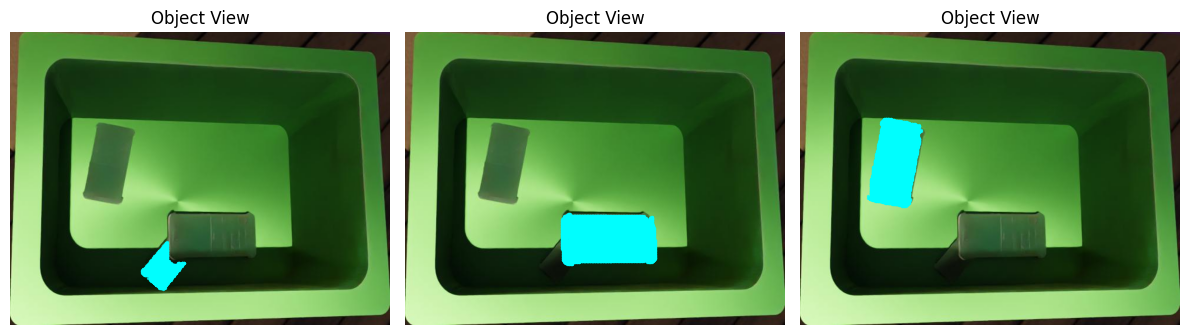

In [5]:
from src.visualize import Visualizer
import matplotlib.pyplot as plt
vis = Visualizer(dataset[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(len(objects)):
    obj = objects[i]
    vis.show_object(
        obj_points=obj["points"],
        ax=axes[i]
    )
plt.tight_layout()
plt.show()